In [1]:
# Import libraries

import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load saved prediction outputs

predictions = pd.read_csv("../data/processed/model_predictions.csv")

predictions.head()

,y_test,y_pred_lr,y_proba_lr,y_pred_rf,y_proba_rf,y_pred_xgb,y_proba_xgb
0,0,0,0.060146,0,0.000,0,0.006181
1,0,0,0.020548,0,0.060,0,0.036321
2,0,0,0.236424,0,0.000,0,0.002582
3,0,0,0.029547,0,0.005,0,0.022047
4,0,0,0.067744,0,0.005,0,0.007815


In [3]:
# Separate actual labels and model predictions

y_test = predictions["y_test"]

y_pred_lr = predictions["y_pred_lr"]
y_proba_lr = predictions["y_proba_lr"]

y_pred_rf = predictions["y_pred_rf"]
y_proba_rf = predictions["y_proba_rf"]

y_pred_xgb = predictions["y_pred_xgb"]
y_proba_xgb = predictions["y_proba_xgb"]

In [4]:
# Logistic Regression evaluation

print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1879
           1       0.76      0.94      0.84       309

    accuracy                           0.95      2188
   macro avg       0.88      0.95      0.91      2188
weighted avg       0.96      0.95      0.95      2188



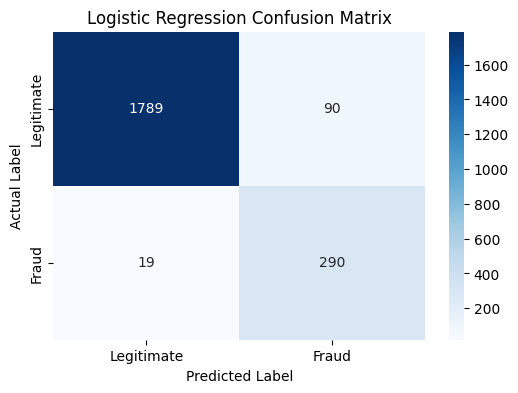

In [13]:
# Generate confusion matrix for Logistic Regression

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

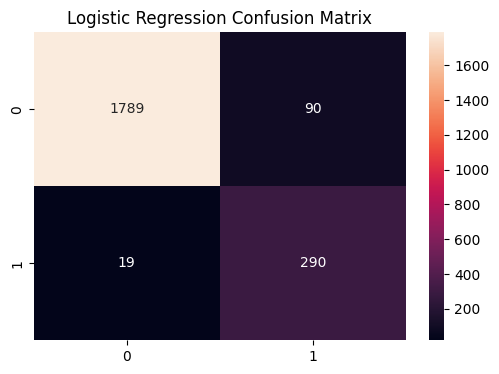

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

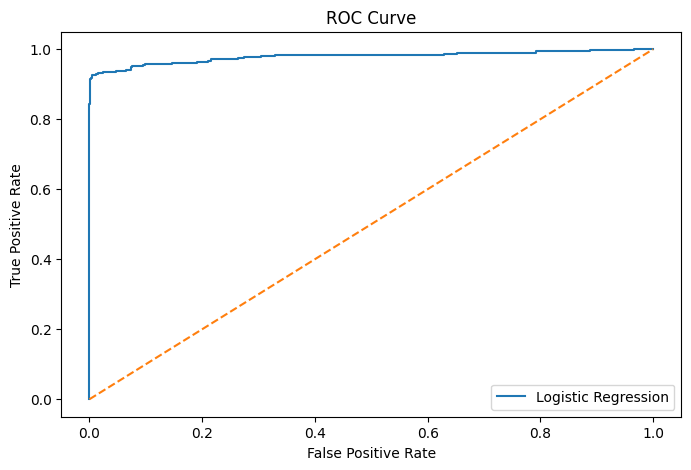

In [8]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_lr
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

Random Forest evaluation

In [6]:
# Random Forest evaluation

print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1879
           1       1.00      0.92      0.96       309

    accuracy                           0.99      2188
   macro avg       0.99      0.96      0.97      2188
weighted avg       0.99      0.99      0.99      2188



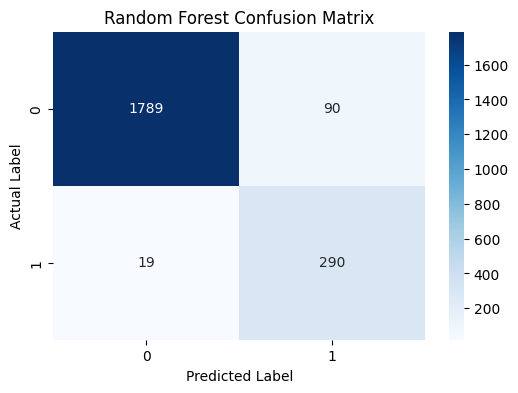

In [7]:
# Visualize confusion matrix

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.show()

In [14]:
# Extract TN, FP, FN, TP

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_lr
).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 1789
False Positives: 90
False Negatives: 19
True Positives : 290


 XGBoost evaluation

In [10]:
# XGBoost evaluation

print("XGBoost Classification Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1879
           1       0.98      0.92      0.95       309

    accuracy                           0.99      2188
   macro avg       0.98      0.96      0.97      2188
weighted avg       0.99      0.99      0.99      2188



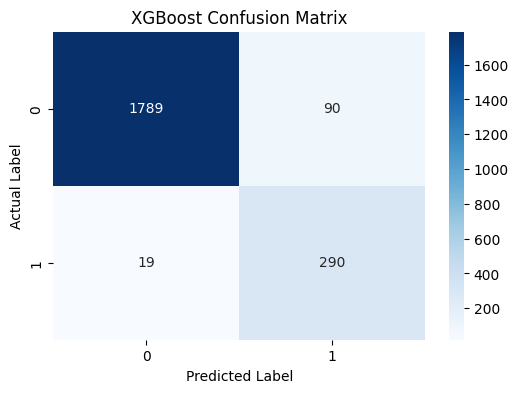

In [11]:
# Visualize confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

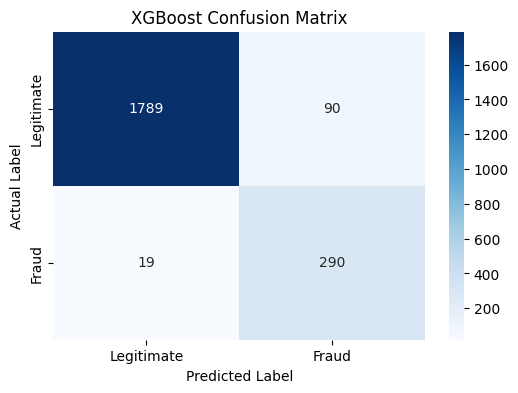

In [12]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Compare all three models on one chart

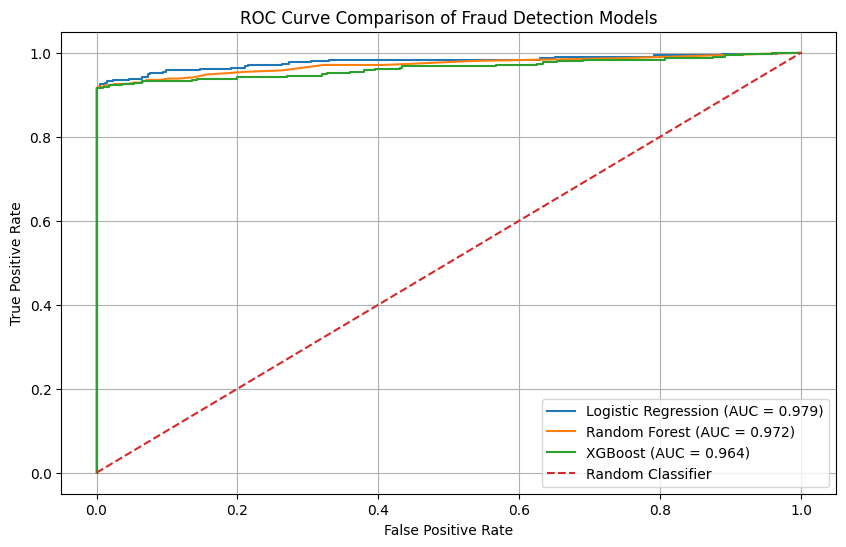

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve values for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_proba_lr
)

# Calculate ROC curve values for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_proba_rf
)

# Calculate ROC curve values for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_proba_xgb
)

# Calculate ROC-AUC scores
auc_lr = roc_auc_score(
    y_test,
    y_proba_lr
)

auc_rf = roc_auc_score(
    y_test,
    y_proba_rf
)

auc_xgb = roc_auc_score(
    y_test,
    y_proba_xgb
)

# Plot all ROC curves on one chart
plt.figure(figsize=(10, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

# Random guessing baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison of Fraud Detection Models")

plt.legend()

plt.grid(True)

plt.show()

| Model               | Precision (Fraud) | Recall (Fraud) | F1-Score (Fraud) |
| ------------------- | ----------------- | -------------- | ---------------- |
| Logistic Regression | 0.93              | 0.81           | 0.87             |
| Random Forest       | 0.99              | 0.83           | 0.90             |
| XGBoost             | 0.98              | 0.92           | 0.95         |


In [18]:
from sklearn.metrics import roc_auc_score

print(
    "Logistic Regression:",
    roc_auc_score(y_test, y_proba_lr)
)

print(
    "Random Forest:",
    roc_auc_score(y_test, y_proba_rf)
)

print(
    "XGBoost:",
    roc_auc_score(y_test, y_proba_xgb)
)

Logistic Regression: 0.9790565456045441
Random Forest: 0.9717728393020457
XGBoost: 0.9637709240782555


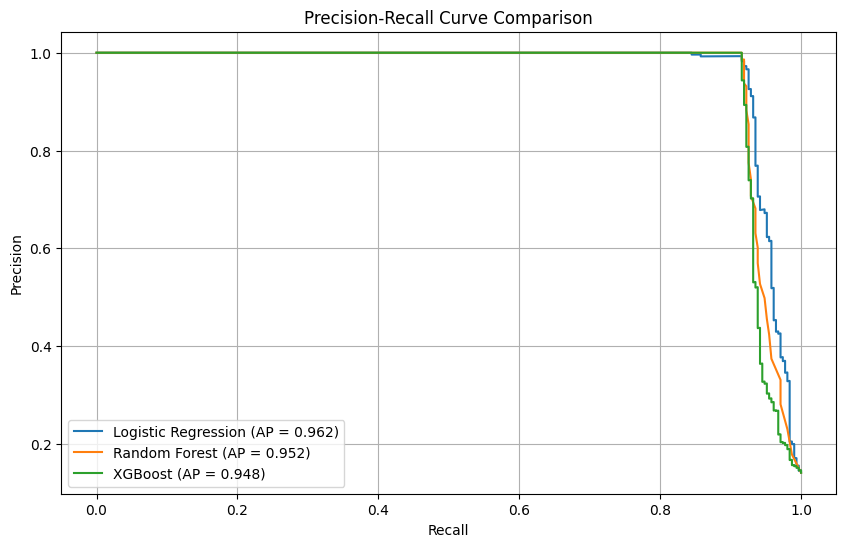

In [21]:
# Import required libraries
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Precision-Recall values

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    y_proba_lr
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_proba_rf
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_proba_xgb
)

# Average Precision Scores

ap_lr = average_precision_score(
    y_test,
    y_proba_lr
)

ap_rf = average_precision_score(
    y_test,
    y_proba_rf
)

ap_xgb = average_precision_score(
    y_test,
    y_proba_xgb
)

# Plot Precision-Recall Curves

plt.figure(figsize=(10, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (AP = {ap_lr:.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP = {ap_rf:.3f})"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (AP = {ap_xgb:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()

plt.grid(True)

plt.show()